# RNN

The RNN I implemented is a function $f_\theta(y, (x_0, x_1, \dots, x_n)) \mapsto (x_1, x_2, \dots, x_{n+1})$ mapping a label $y$ and previous sequence to a new sequence which drops the first value and predicts a new last value. Training is done by minimizing

$\frac{1}{n} e^\intercal e$  where $e = (x_1, x_2, \dots, x_{n+1}) - f_\theta(y, (x_0, x_1, \dots, x_n))$  



In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import util

def create_dataset(df):
    sensor_data = df['sensor_data'].apply(lambda x: np.array(x, dtype=np.float32))
    X = np.stack(sensor_data.values)
    y = df['label'].values
    y = np.array([util.label_to_tuple(label) for label in y])

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    return dataset

original_train = pd.read_pickle('../../data/train.pickle')
original_test = pd.read_pickle('../../data/test.pickle')
train_dataset = create_dataset(original_train)
test_dataset = create_dataset(original_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

class RNN(nn.Module):
    def __init__(self, num_classes=4, hidden_size=256):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # Input size becomes (original features + label)
        self.rnn = nn.LSTM(
            input_size=6 + num_classes,  # 6 sensor features + 4 label dims
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size//2, 6),
        )

    def forward(self, label, x):
        batch_size, seq_len, _ = x.size()
        label_seq = label.unsqueeze(1).expand(-1, seq_len, -1)
        x_with_label = torch.cat([x, label_seq], dim=2)
        out, _ = self.rnn(x_with_label)
        out = self.fc(out)  # shape: (batch_size, seq_len, 6)
        return out
    

model = RNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 100

## Training Loop
In the training loop, for each batch of data, we perform many-to-many prediction.


In [ ]:
model.to(device)
model.train()

for epoch in range(EPOCHS):
    for i, (features, labels) in enumerate(train_loader):
        optimizer.zero_grad() 
        features = features.to(device)     # (batch, seq_len, 6)
        labels = labels.to(device)         # (batch, 4)
        inputs = features[:, :-1, :]       # (batch, seq_len - 1, 6)
        targets = features[:, 1:, :]       # (batch, seq_len - 1, 6)
        preds = model(labels, inputs)      # (batch, seq_len - 1, 6)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch + 1}/{EPOCHS}], Loss: {loss.item():.4f}')

torch.save(model.state_dict(), 'rnn.pth')

## Inference Demo

tensor([[0., 0., 0., 1.]])


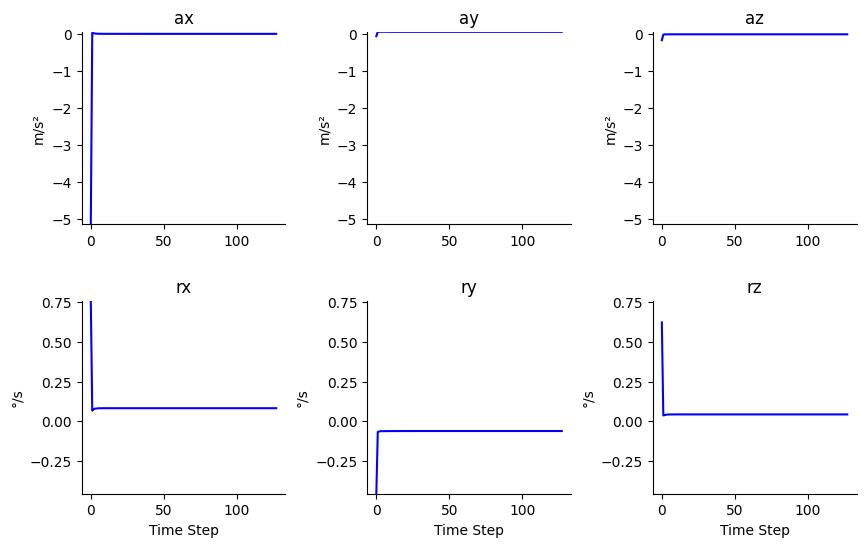

In [ ]:
import util
import visualize


model.cpu()
model.load_state_dict(torch.load('rnn.pth'))
model.eval()

def generate_sequence(model, label, start_sequence, seq_length=128):
    model.eval()
    generated = start_sequence.clone().cpu()
    label = label.cpu()

    for _ in range(seq_length - start_sequence.shape[1]):
        with torch.no_grad():
            out = model(label, generated)
            next_elem = out[:, -1:, :]
            generated = torch.cat([generated, next_elem], dim=1)
    return generated

# Get a random sample from the training data
idx = np.random.randint(len(train_dataset))
sample_features, sample_label = train_dataset[idx]

# Use only the first value as the start_sequence
start_sequence = sample_features[:1].unsqueeze(0).cpu() 
label_tensor = sample_label.unsqueeze(0).cpu()
seq_length = sample_features.shape[0]
print(label_tensor)
# Generate a sequence
generated = generate_sequence(model, label_tensor, start_sequence, seq_length=seq_length)
visualize.plot_data(generated[0])

